In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [68]:
df=pd.read_csv("loan_approval_data.csv")

In [69]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [70]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [71]:
#handle missing values
categorical_col=df.select_dtypes(include=["object"]).columns
numerical_col=df.select_dtypes(include=["float64"]).columns

In [72]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_col]=num_imp.fit_transform(df[numerical_col])
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_col]=cat_imp.fit_transform(df[categorical_col])

In [73]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

([<matplotlib.patches.Wedge at 0x19667cb9e50>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'no'),
  Text(0.6521428261765839, -0.8858384357581341, 'yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

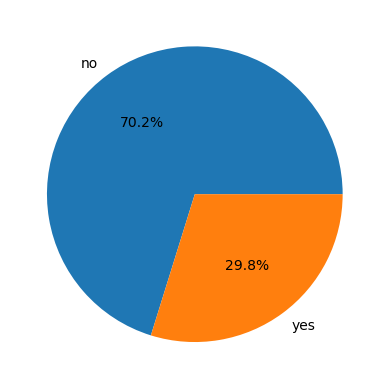

In [74]:
#EDA
count=df["Loan_Approved"].value_counts()
plt.pie(count,labels=["no","yes"],autopct="%1.1f%%")

<Axes: xlabel='Gender', ylabel='count'>

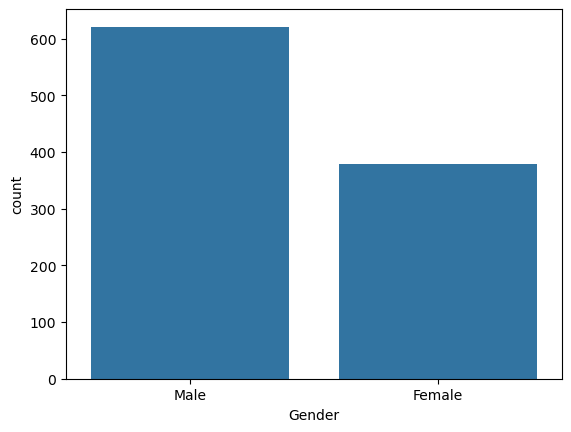

In [75]:
gender=df["Gender"].value_counts()
sns.barplot(gender)

<Axes: xlabel='Education_Level', ylabel='count'>

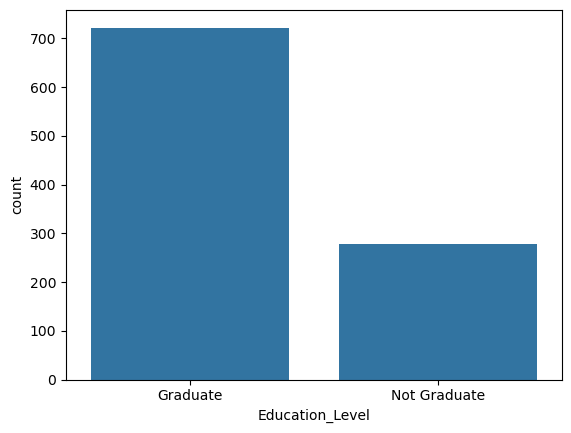

In [76]:
edu=df["Education_Level"].value_counts()
sns.barplot(edu)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

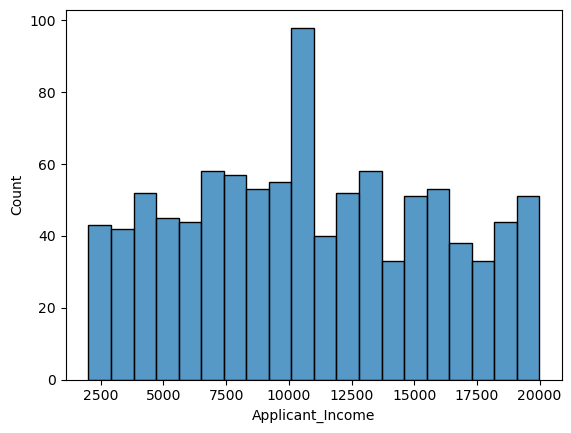

In [77]:
#analyse income
sns.histplot(data=df,x="Applicant_Income",bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

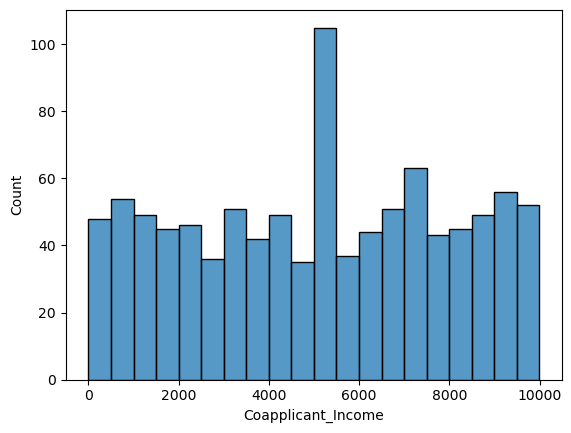

In [78]:
sns.histplot(data=df,x="Coapplicant_Income",bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

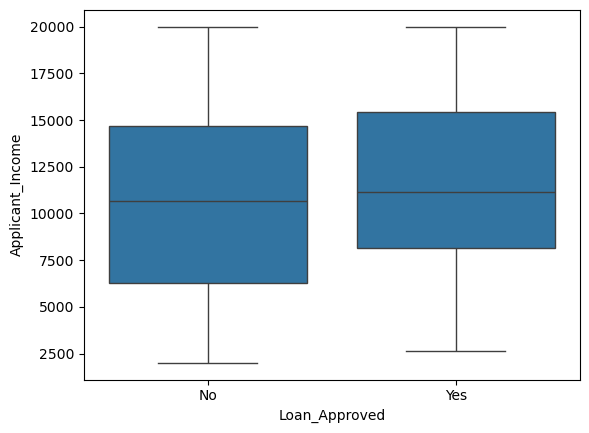

In [79]:
sns.boxplot(data=df,x="Loan_Approved",y="Applicant_Income")

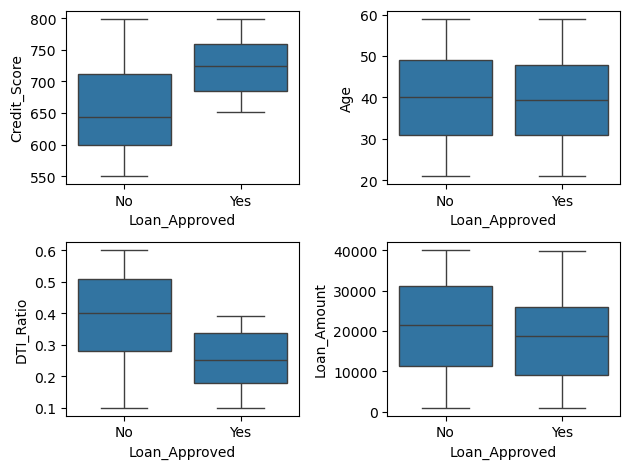

In [80]:
fig,ax=plt.subplots(2,2)
sns.boxplot(ax=ax[0][0],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=ax[0][1],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=ax[1][0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=ax[1][1],data=df,x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

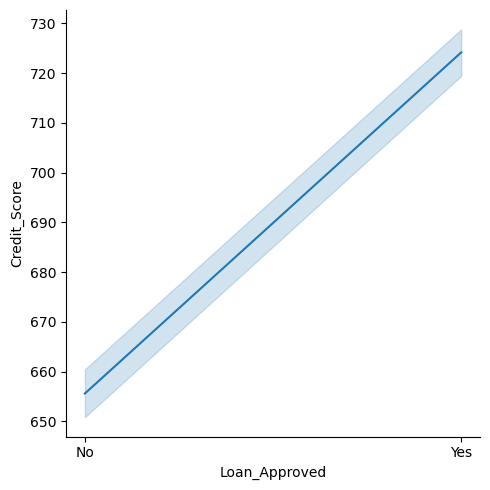

In [81]:
sns.relplot(data=df,x="Loan_Approved",y="Credit_Score",kind="line")
plt.tight_layout()

In [82]:
df=df.drop("Applicant_ID",axis=1)

In [83]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [84]:
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [85]:
one=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
encoded=one.fit_transform(df[cols])

In [86]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [87]:
data=pd.DataFrame(encoded,columns=one.get_feature_names_out(cols),index=df.index)

In [88]:
df=pd.concat([df.drop(columns=cols),data],axis=1)

In [89]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


<Axes: >

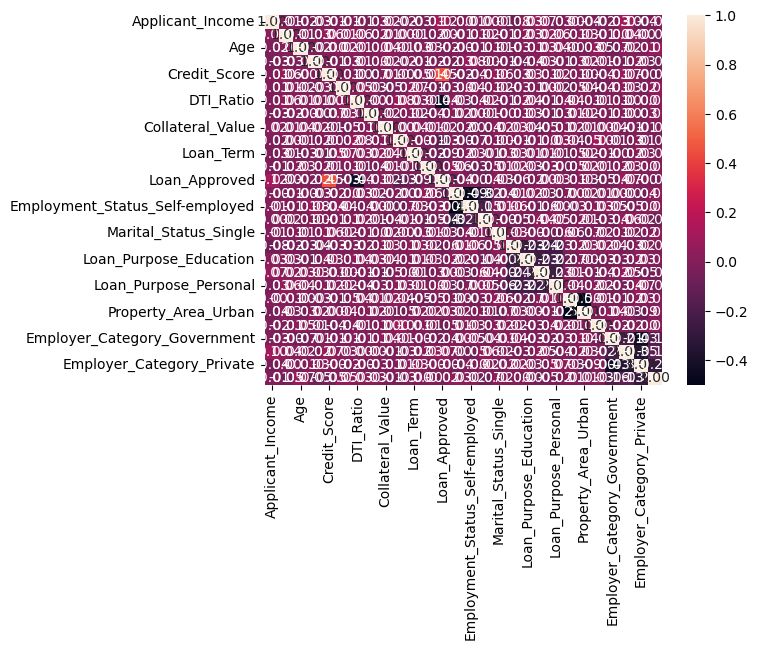

In [90]:
nums_col=df.select_dtypes(include="number")
corr_matrix=nums_col.corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f")

In [91]:
nums_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [92]:
#Feature Engineering
df["DTI_ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_score_sq"]=df["Credit_Score"]**2
df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])
X=df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score","Applicant_Income"])
y=df["Loan_Approved"]


In [31]:
#train test split 
#Naive Bayes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)
nb = GaussianNB()
nb.fit(X_train_scale,y_train)
pred3=nb.predict(X_test_scale)
print("precision:",precision_score(y_test,pred3))
print("recall:",recall_score(y_test,pred3))
print("accuracy:",accuracy_score(y_test,pred3))
print("CM:",confusion_matrix(y_test,pred3))



precision: 0.8035714285714286
recall: 0.7377049180327869
accuracy: 0.865
CM: [[128  11]
 [ 16  45]]


In [32]:
#KNN
k_model=KNeighborsClassifier(n_neighbors=5)
k_model.fit(X_train_scale,y_train)
pred2=k_model.predict(X_test_scale)
print("precision:",precision_score(y_test,pred2))
print("recall:",recall_score(y_test,pred2))
print("accuracy:",accuracy_score(y_test,pred2))
print("CM:",confusion_matrix(y_test,pred2))

precision: 0.6296296296296297
recall: 0.5573770491803278
accuracy: 0.765
CM: [[119  20]
 [ 27  34]]


In [33]:
#Logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train_scale,y_train)
pred1=log_model.predict(X_test_scale)
print("precision:",precision_score(y_test,pred1))
print("recall:",recall_score(y_test,pred1))
print("accuracy:",accuracy_score(y_test,pred1))
print("CM:",confusion_matrix(y_test,pred1))

precision: 0.7777777777777778
recall: 0.8032786885245902
accuracy: 0.87
CM: [[125  14]
 [ 12  49]]


In [34]:
print("The final Model: Gaussian Naive Bayes")

The final Model: Gaussian Naive Bayes


In [35]:
import joblib
# Save the trained Naive Bayes model
joblib.dump(nb, "naive_bayes_model.pkl")
# Save the scaler used during training
joblib.dump(scaler, "scaler.pkl")
print("Naive Bayes model saved successfully!")
print("Scaler saved successfully!")

Naive Bayes model saved successfully!
Scaler saved successfully!


In [43]:
# Test that the saved model and scaler work correctly
import joblib
# Load saved files
loaded_nb = joblib.load("naive_bayes_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Scale test data
X_test_scaled_loaded = loaded_scaler.transform(X_test)

# Make predictions
test_prediction = loaded_nb.predict(X_test_scale)

# Check performance
print("Saved Model Performance")
print("-----------------------")
print("Precision:", precision_score(y_test, pred3))
print("Recall:", recall_score(y_test,pred3))
print("Accuracy:", accuracy_score(y_test, pred3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred3))

Saved Model Performance
-----------------------
Precision: 0.8035714285714286
Recall: 0.7377049180327869
Accuracy: 0.865

Confusion Matrix:
[[128  11]
 [ 16  45]]


In [44]:
joblib.dump(nb, "naive_bayes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [46]:
joblib.dump(one, "onehot_encoder.pkl")
print("OneHotEncoder saved successfully!")

OneHotEncoder saved successfully!


In [47]:
from sklearn.preprocessing import LabelEncoder
education_encoder = LabelEncoder()
education_encoder.fit(["Graduate", "Not Graduate"])
joblib.dump(education_encoder, "education_encoder.pkl")
print("Education encoder saved successfully!")

Education encoder saved successfully!


In [48]:
print(X.columns.tolist())

['Coapplicant_Income', 'Age', 'Dependents', 'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed', 'DTI_ratio_sq', 'Credit_score_sq', 'Applicant_Income_log']


In [50]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(nb, "naive_bayes_model.pkl")

['naive_bayes_model.pkl']

In [51]:
print(scaler.n_features_in_)

27
